# **CogniDetect: Deep Learning Approaches for Brain Tumour and Alzheimer's Detection**


## **Dataset**
1. Brain Tumor Dataset: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri/data
2. Alzheimer's Dataset: https://www.kaggle.com/datasets/tourist55/alzheimers-dataset-4-class-of-images/data


## **Features**

1. Brain Tumor Dataset:
    
    * glioma_tumor

    * no_tumor

    * meningioma_tumor

    * pituitary_tumor

1. Alzheimer's Dataset:
    
    * Mild Demented

    * Moderate Demented

    * Non Demented

    * Very Mild Demented

## **Preparing the tools**


In [ ]:
!pip install pydot

In [ ]:
!pip install tensorflow

In [ ]:
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 34.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 64.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.2 MB/s eta 0:00:00


In [ ]:
# Import all the tools we need
import time
import cv2
from tqdm import tqdm
import io
import os

# Regular EDA (Exploratory Data Analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# we want our plots to appear inside the notebook
%matplotlib inline

# Import necessary tools for modelling
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D, Concatenate, Dropout, Dense, Flatten
from tensorflow.keras.metrics import Precision, Recall


In [ ]:
!pip install opencv-python

## **Load Data**

### **1. Brain Tumor:**

In [ ]:
X_train_bt = []
y_train_bt = []
labels_bt = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

image_size = 256
for i in labels_bt:
    folderPath = os.path.join(r'Brain Tumuor/Training',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        if img is not None:
            img = cv2.resize(img, (image_size, image_size))
            X_train_bt.append(img)
            y_train_bt.append(i)

for i in labels_bt:
    folderPath = os.path.join(r'Brain Tumuor/Testing',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        if img is not None:
            img = cv2.resize(img, (image_size, image_size))
            X_train_bt.append(img)
            y_train_bt.append(i)

X_train_bt = np.array(X_train_bt)
y_train_bt = np.array(y_train_bt)

100%|██████████| 74/74 [00:01<00:00, 61.95it/s]


### **2. Alzheimer's**

In [ ]:
X_train_al = []
y_train_al = []
labels_al = ['MildDemented','ModerateDemented','NonDemented','VeryMildDemented']

image_size = 256
for i in labels_al:
    folderPath = os.path.join(r'Alzheimer_s/Alzheimer_s Dataset/train',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train_al.append(img)
        y_train_al.append(i)

for i in labels_al:
    folderPath = os.path.join(r'Alzheimer_s/Alzheimer_s Dataset/test',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train_al.append(img)
        y_train_al.append(i)

X_train_al = np.array(X_train_al)
y_train_al = np.array(y_train_al)

100%|██████████| 448/448 [00:02<00:00, 149.84it/s]


### **3. Both Alzheimer's and Brain Tumor**

In [ ]:
X_train_al_bt = []
y_train_al_bt = []
labels_al_bt = ['MildDemented','ModerateDemented','NonDemented','VeryMildDemented','glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

image_size = 256
for i in labels_al_bt:
    folderPath = os.path.join(r'bt_al/Training',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train_al_bt.append(img)
        y_train_al_bt.append(i)

for i in labels_al_bt:
    folderPath = os.path.join(r'bt_al/Testing',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train_al_bt.append(img)
        y_train_al_bt.append(i)

X_train_al_bt = np.array(X_train_al_bt)
y_train_al_bt = np.array(y_train_al_bt)

100%|██████████| 74/74 [00:01<00:00, 63.10it/s]


## **Visualizatioin**

**1. Brain Tumor**:


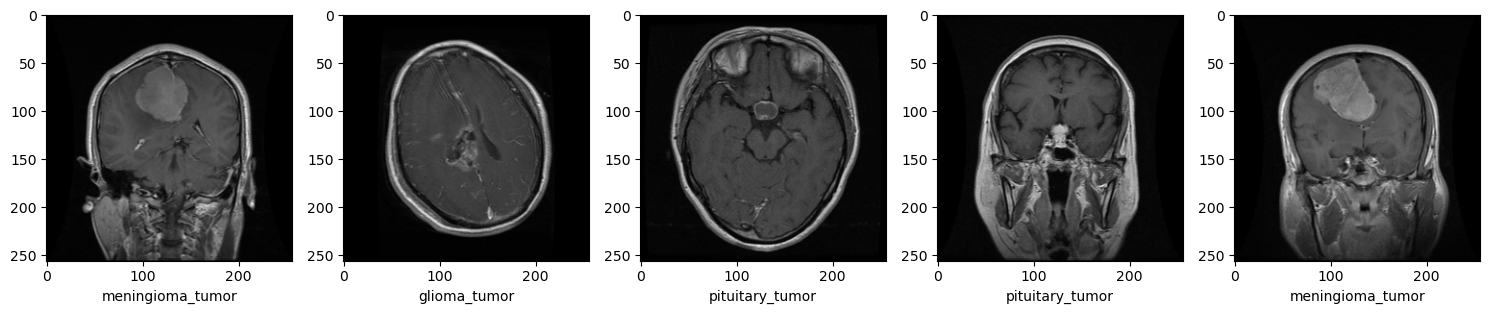

In [ ]:
plt.figure(figsize=(15, 15))

random_indices = np.random.choice(len(X_train_bt), size=5, replace=False)
for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_bt[idx])
    plt.xlabel(y_train_bt[idx])
    plt.tight_layout()
plt.show()

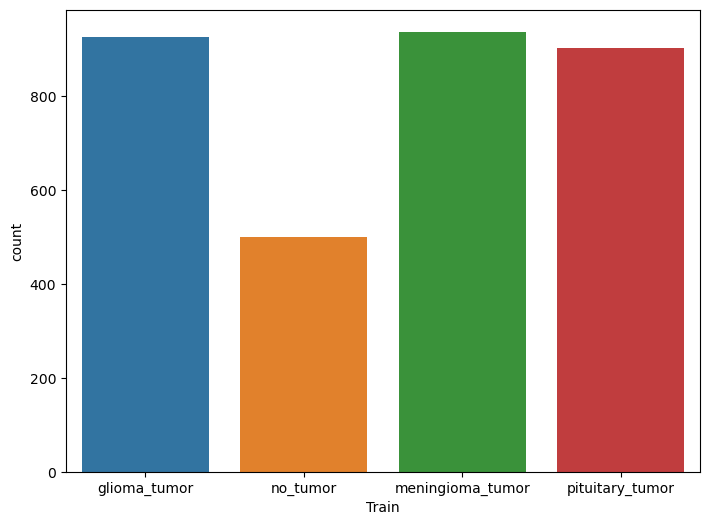

In [ ]:
plt.figure(figsize = (18,6));
lis = ['Train']
for i,j in enumerate([y_train_bt]):
    plt.subplot(1,2, i+1)
    sns.countplot(x = j)
    plt.xlabel(lis[i])

## **Data Augmentation**


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest')

datagen.fit(X_train_bt)

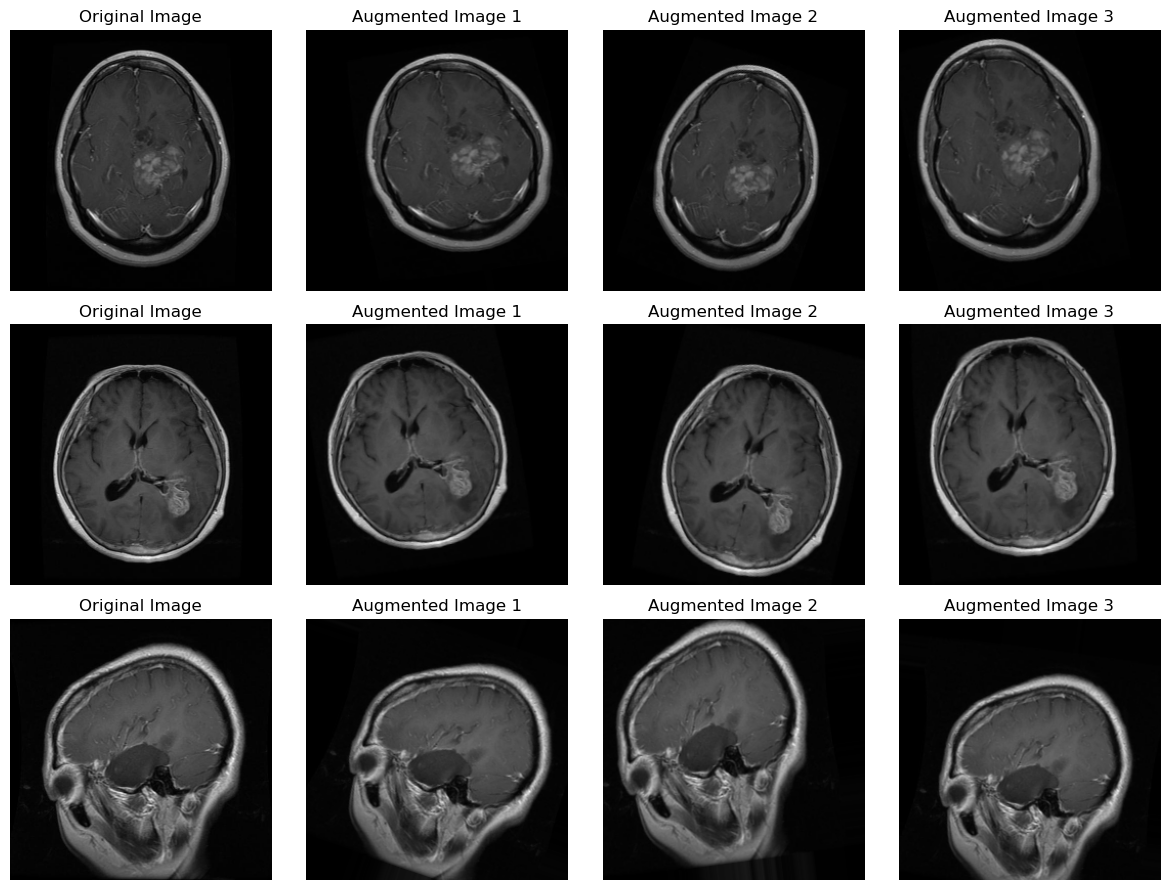

In [ ]:
def visualize_augmented_images(image_generator, num_samples, num_augmented_images):
    augmented_images = []
    for sample in X_train_bt[:num_samples]:

        # Create a list to store augmented versions of a sample
        augmented_samples = [sample]
        for _ in range(num_augmented_images):
            augmented_samples.append(image_generator.random_transform(sample))
        augmented_images.append(augmented_samples)

    # Plot original and augmented images
    fig, axes = plt.subplots(num_samples, num_augmented_images + 1, figsize=( 12, num_samples * 3))
    for i, sample in enumerate(augmented_images):
        for j, image in enumerate(sample):
            axes[i,j].imshow(image)
            if j == 0:
                axes[i, j].set_title('Original Image')
            else:
                axes[i,j].set_title(f'Augmented Image {j}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

#Visualize augmented images to see how it works
visualize_augmented_images(datagen, num_samples=3, num_augmented_images=3)

* Now shuffle X_train_bt and y_train_bt dataset.

In [ ]:
X_train_bt, y_train_bt = shuffle(X_train_bt, y_train_bt, random_state = 101)
X_train_bt.shape, y_train_bt.shape

((3264, 256, 256, 3), (3264,))

#### Now split data into test and train datasets

In [ ]:
X_train_bt, X_test_bt, y_train_bt, y_test_bt = train_test_split(X_train_bt, y_train_bt, test_size = 0.1, random_state = 101)

In [ ]:
y_train_new_bt = []
for i in y_train_bt:
    y_train_new_bt.append(labels_bt.index(i))

y_train_bt = y_train_new_bt
y_train_bt = tf.keras.utils.to_categorical(y_train_bt)

y_test_new_bt = []
for i in y_test_bt:
    y_test_new_bt.append(labels_bt.index(i))

y_test_bt = y_test_new_bt
y_test_bt = tf.keras.utils.to_categorical(y_test_bt)

## **Modelling - 3D Unets**

In [ ]:
def conv_block(input_tensor, num_filters):
    encoder = Conv3D(num_filters, (3, 3, 3), activation='relu', padding='same')(input_tensor)
    encoder = Conv3D(num_filters, (3, 3, 3), activation='relu', padding='same')(encoder)
    return encoder

def unet_3d(input_shape, num_classes):
    inputs = Input(input_shape)

    # Contracting Path
    conv1 = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(inputs)
    pool1 = MaxPooling3D(pool_size=(2, 2, 2))(conv1)
    conv2 = Conv3D(128, (3, 3, 3), activation='relu', padding='same')(pool1)
    pool2 = MaxPooling3D(pool_size=(2, 2, 2))(conv2)
    conv3 = Conv3D(256, (3, 3, 3), activation='relu', padding='same')(pool2)
    pool3 = MaxPooling3D(pool_size=(2, 2, 2))(conv3)

    # Bottom
    conv4 = Conv3D(512, (3, 3, 3), activation='relu', padding='same')(pool3)

    # Expanding Path
    up5 = Conv3D(256, (2, 2, 2), activation='relu', padding='same')(UpSampling3D(size=(2, 2, 2))(conv4))
    up5 = Conv3D(256, (3, 3, 3), activation='relu', padding='same')(up5)
    merge5 = Concatenate()([conv3, up5])
    conv5 = Conv3D(256, (3, 3, 3), activation='relu', padding='same')(merge5)

    up6 = Conv3D(128, (2, 2, 2), activation='relu', padding='same')(UpSampling3D(size=(2, 2, 2))(conv5))
    merge6 = Concatenate()([conv2, up6])
    conv6 = Conv3D(128, (3, 3, 3), activation='relu', padding='same')(merge6)

    up7 = Conv3D(64, (2, 2, 2), activation='relu', padding='same')(UpSampling3D(size=(2, 2, 2))(conv6))
    merge7 = Concatenate()([conv1, up7])
    conv7 = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(merge7)

    conv8 = Conv3D(num_classes, (1, 1, 1), activation='softmax')(conv7)

    return Model(inputs=inputs, outputs=conv8)

# Define input shape and number of classes
input_shape = (256, 256, 256, 3)  # Adjust input shape based on your data
num_classes = 4  # Adjust based on the number of classes

model_bt = unet_3d(input_shape, num_classes)

In [ ]:
model_bt.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 256, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_36 (Conv3D)  │ (None, 256, 256,  │      5,248 │ input_layer_9[0]… │
│                     │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_9     │ (None, 128, 128,  │          0 │ conv3d_36[0][0]   │
│ (MaxPooling3D)      │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_37 (Conv3D)  │ (None, 128, 128,  │    221,312 │ max_pooling3d_9[… │
│                     │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_10    │ (None, 64, 64,    │          0 │ conv3d_37[0][0]   │
│ (MaxPooling3D)      │ 64, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_38 (Conv3D)  │ (None, 64, 64,    │    884,992 │ max_pooling3d_10… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_11    │ (None, 32, 32,    │          0 │ conv3d_38[0][0]   │
│ (MaxPooling3D)      │ 32, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_39 (Conv3D)  │ (None, 32, 32,    │  3,539,456 │ max_pooling3d_11… │
│                     │ 32, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_9     │ (None, 64, 64,    │          0 │ conv3d_39[0][0]   │
│ (UpSampling3D)      │ 64, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_40 (Conv3D)  │ (None, 64, 64,    │  1,048,832 │ up_sampling3d_9[… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_41 (Conv3D)  │ (None, 64, 64,    │  1,769,728 │ conv3d_40[0][0]   │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_27      │ (None, 64, 64,    │          0 │ conv3d_38[0][0],  │
│ (Concatenate)       │ 64, 512)          │            │ conv3d_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_42 (Conv3D)  │ (None, 64, 64,    │  3,539,200 │ concatenate_27[0… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_10    │ (None, 128, 128,  │          0 │ conv3d_42[0][0]   │
│ (UpSampling3D)      │ 128, 256)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_43 (Conv3D)  │ (None, 128, 128,  │    262,272 │ up_sampling3d_10… │
│                     │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_28      │ (None, 128, 128,  │          0 │ conv3d_37[0][0],  │
│ (Concatenate)       │ 128, 256)         │            │ conv3d_43[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_44 (Conv3D)  │ (None, 128, 128,  │    884,864 │ concatenate_28[0

 Total params: 12,443,012 (47.47 MB)

 Trainable params: 12,443,012 (47.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_bt.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [ ]:
history_bt = model_bt.fit(X_train_bt, y_train_bt, epochs = 50, validation_split = 0.1)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1306s 15s/step - accuracy: 0.2828 - loss: 2.0073 - val_accuracy: 0.3265 - val_loss: 1.3270
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1243s 15s/step - accuracy: 0.4375 - loss: 1.2625 - val_accuracy: 0.3401 - val_loss: 1.2912
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 896s 11s/step - accuracy: 0.5031 - loss: 1.1318 - val_accuracy: 0.5340 - val_loss: 1.1565
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1362s 16s/step - accuracy: 0.5548 - loss: 1.0544 - val_accuracy: 0.4966 - val_loss: 1.2242
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1267s 15s/step - accuracy: 0.5539 - loss: 1.0241 - val_accuracy: 0.5272 - val_loss: 1.2003
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 51701s 630s/step - accuracy: 0.6040 - loss: 0.9408 - val_accuracy: 0.5136 - val_loss: 1.1707
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 643s 8s/step - accuracy: 0.5945 - loss: 0.9520 - val_accuracy: 0.4524 - val_loss: 2.9024
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 656s 8s/step - accuracy: 0.5488 - loss: 1.0494 - val_accurac

In [ ]:
test_metrics_bt = model_bt.evaluate(X_test_bt, y_test_bt)

# Print the test metrics
print("Test Metrics:")
print("Loss:", test_metrics_bt[0])
print("Accuracy:", test_metrics_bt[1])

11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.8575 - loss: 0.5600
Test Metrics:
Loss: 0.643735945224762
Accuracy: 0.8593271970748901


**2. Alzheimer's**:


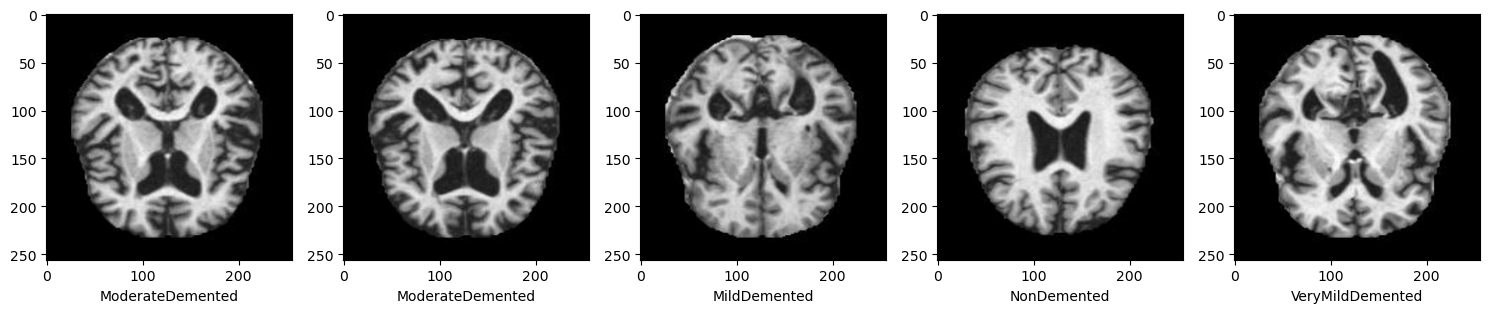

In [ ]:
plt.figure(figsize=(15, 15))

random_indices = np.random.choice(len(X_train_al), size=5, replace=False)
for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_al[idx])
    plt.xlabel(y_train_al[idx])
    plt.tight_layout()
plt.show()

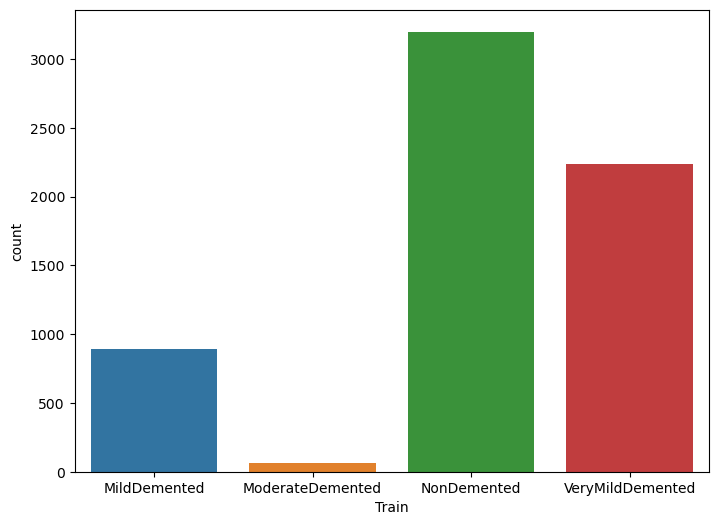

In [ ]:
plt.figure(figsize = (18,6));
lis = ['Train']
for i,j in enumerate([y_train_al]):
    plt.subplot(1,2, i+1)
    sns.countplot(x = j)
    plt.xlabel(lis[i])

* Now shuffle X_train and y_train dataset.

In [ ]:
X_train_al, y_train_al = shuffle(X_train_al, y_train_al, random_state = 101)
X_train_al.shape, y_train_al.shape

((6400, 256, 256, 3), (6400,))

#### Now split data into test and train datasets

In [ ]:
X_train_al, X_test_al, y_train_al, y_test_al = train_test_split(X_train_al, y_train_al, test_size = 0.1, random_state = 101)

In [ ]:
y_train_new_al = []
for i in y_train_al:
    y_train_new_al.append(labels_al.index(i))

y_train_al = y_train_new_al
y_train_al = tf.keras.utils.to_categorical(y_train_al)

y_test_new_al = []
for i in y_test_al:
    y_test_new_al.append(labels_al.index(i))

y_test_al = y_test_new_al
y_test_al = tf.keras.utils.to_categorical(y_test_al)

## **Modelling**

In [ ]:
model_al = unet_3d(input_shape, num_classes)

In [ ]:
model_al.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 256, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_12 (Conv3D)  │ (None, 256, 256,  │      5,248 │ input_layer_4[0]… │
│                     │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 128, 128,  │          0 │ conv3d_12[0][0]   │
│ (MaxPooling3D)      │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_13 (Conv3D)  │ (None, 128, 128,  │    221,312 │ max_pooling3d_3[… │
│                     │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 64, 64,    │          0 │ conv3d_13[0][0]   │
│ (MaxPooling3D)      │ 64, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_14 (Conv3D)  │ (None, 64, 64,    │    884,992 │ max_pooling3d_4[… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_5     │ (None, 32, 32,    │          0 │ conv3d_14[0][0]   │
│ (MaxPooling3D)      │ 32, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_15 (Conv3D)  │ (None, 32, 32,    │  3,539,456 │ max_pooling3d_5[… │
│                     │ 32, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_3     │ (None, 64, 64,    │          0 │ conv3d_15[0][0]   │
│ (UpSampling3D)      │ 64, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_16 (Conv3D)  │ (None, 64, 64,    │  1,048,832 │ up_sampling3d_3[… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_17 (Conv3D)  │ (None, 64, 64,    │  1,769,728 │ conv3d_16[0][0]   │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 64, 64,    │          0 │ conv3d_14[0][0],  │
│ (Concatenate)       │ 64, 512)          │            │ conv3d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_18 (Conv3D)  │ (None, 64, 64,    │  3,539,200 │ concatenate_12[0… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_4     │ (None, 128, 128,  │          0 │ conv3d_18[0][0]   │
│ (UpSampling3D)      │ 128, 256)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_19 (Conv3D)  │ (None, 128, 128,  │    262,272 │ up_sampling3d_4[… │
│                     │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 128, 128,  │          0 │ conv3d_13[0][0],  │
│ (Concatenate)       │ 128, 256)         │            │ conv3d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_20 (Conv3D)  │ (None, 128, 128,  │    884,864 │ concatenate_13[0

 Total params: 12,443,012 (47.47 MB)

 Trainable params: 12,443,012 (47.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_al.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [ ]:
history_al = model_al.fit(X_train_al, y_train_al, epochs = 50, validation_split = 0.1)

Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 1403s 9s/step - accuracy: 0.4463 - loss: 1.2057 - val_accuracy: 0.5069 - val_loss: 1.0118
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 1395s 9s/step - accuracy: 0.5023 - loss: 1.0223 - val_accuracy: 0.5069 - val_loss: 0.9919
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 1399s 9s/step - accuracy: 0.4929 - loss: 1.0186 - val_accuracy: 0.5069 - val_loss: 1.0168
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2341s 14s/step - accuracy: 0.5030 - loss: 1.0154 - val_accuracy: 0.5556 - val_loss: 1.0131
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2706s 17s/step - accuracy: 0.5290 - loss: 0.9821 - val_accuracy: 0.5538 - val_loss: 0.9443
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2715s 17s/step - accuracy: 0.5381 - loss: 0.9559 - val_accuracy: 0.5903 - val_loss: 0.9644
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2565s 16s/step - accuracy: 0.5621 - loss: 0.9131 - val_accuracy: 0.6076 - val_loss: 0.9146
Epoch 8/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 1889s 12s/step - accuracy: 0.5578 - loss: 0.92

In [ ]:
test_metrics_al = model_al.evaluate(X_test_al, y_test_al)

# Print the test metrics
print("Test Metrics:")
print("Loss:", test_metrics_al[0])
print("Accuracy:", test_metrics_al[1])


20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.8508 - loss: 0.5090
Test Metrics:
Loss: 0.5230598449707031
Accuracy: 0.8359375


### ***Now let us train both the datasets together***

### **Training both Brain Tumor and Alzhemiers Dataset together**

#### **Visualization**

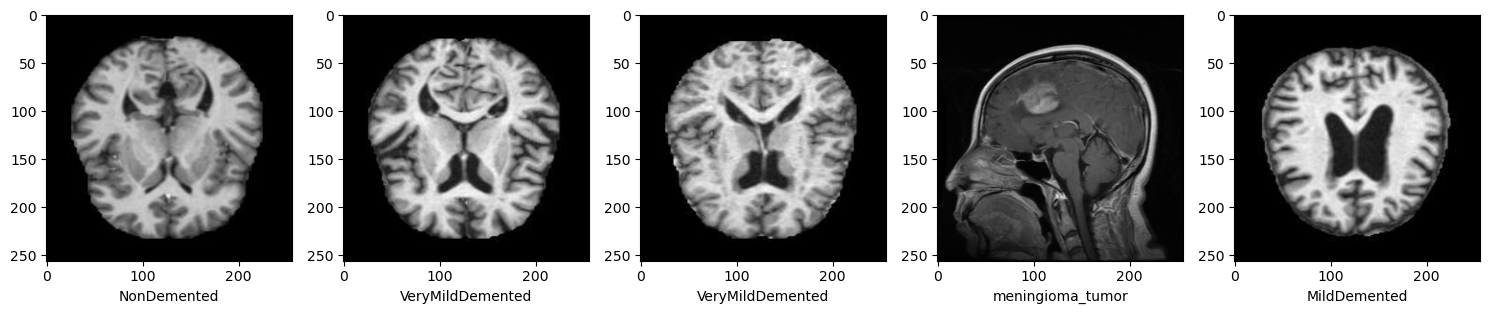

In [ ]:
plt.figure(figsize=(15, 15))

random_indices = np.random.choice(len(X_train_al_bt), size=5, replace=False)
for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_al_bt[idx])
    plt.xlabel(y_train_al_bt[idx])
    plt.tight_layout()
plt.show()

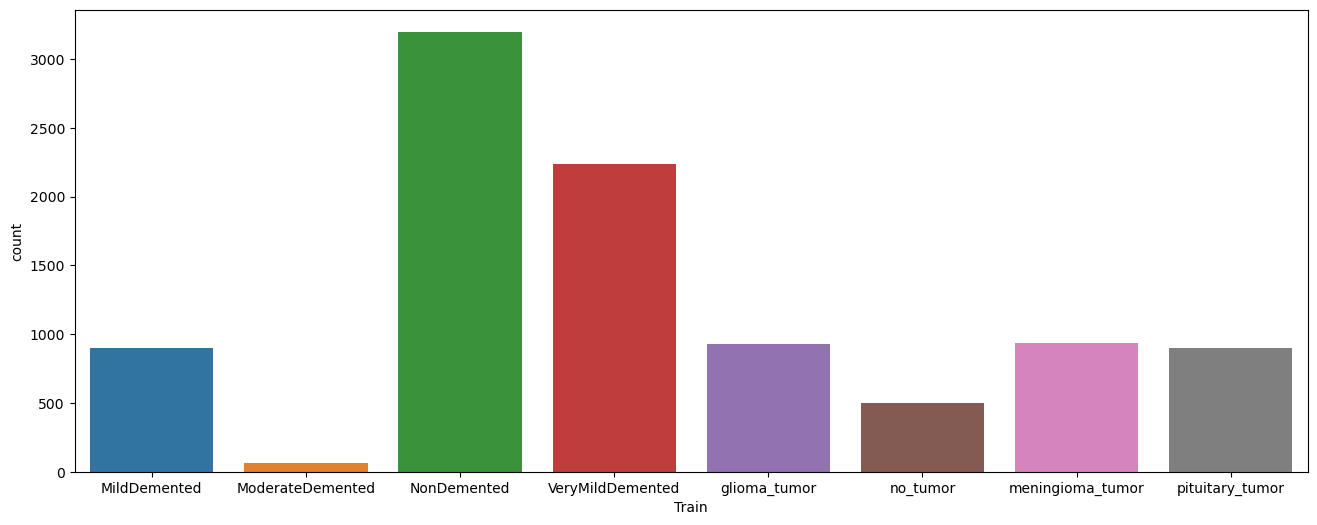

In [ ]:
plt.figure(figsize = (35,6));
lis = ['Train']
for i,j in enumerate([y_train_al_bt]):
    plt.subplot(1,2, i+1)
    sns.countplot(x = j)
    plt.xlabel(lis[i])

In [ ]:
datagen.fit(X_train_al_bt)

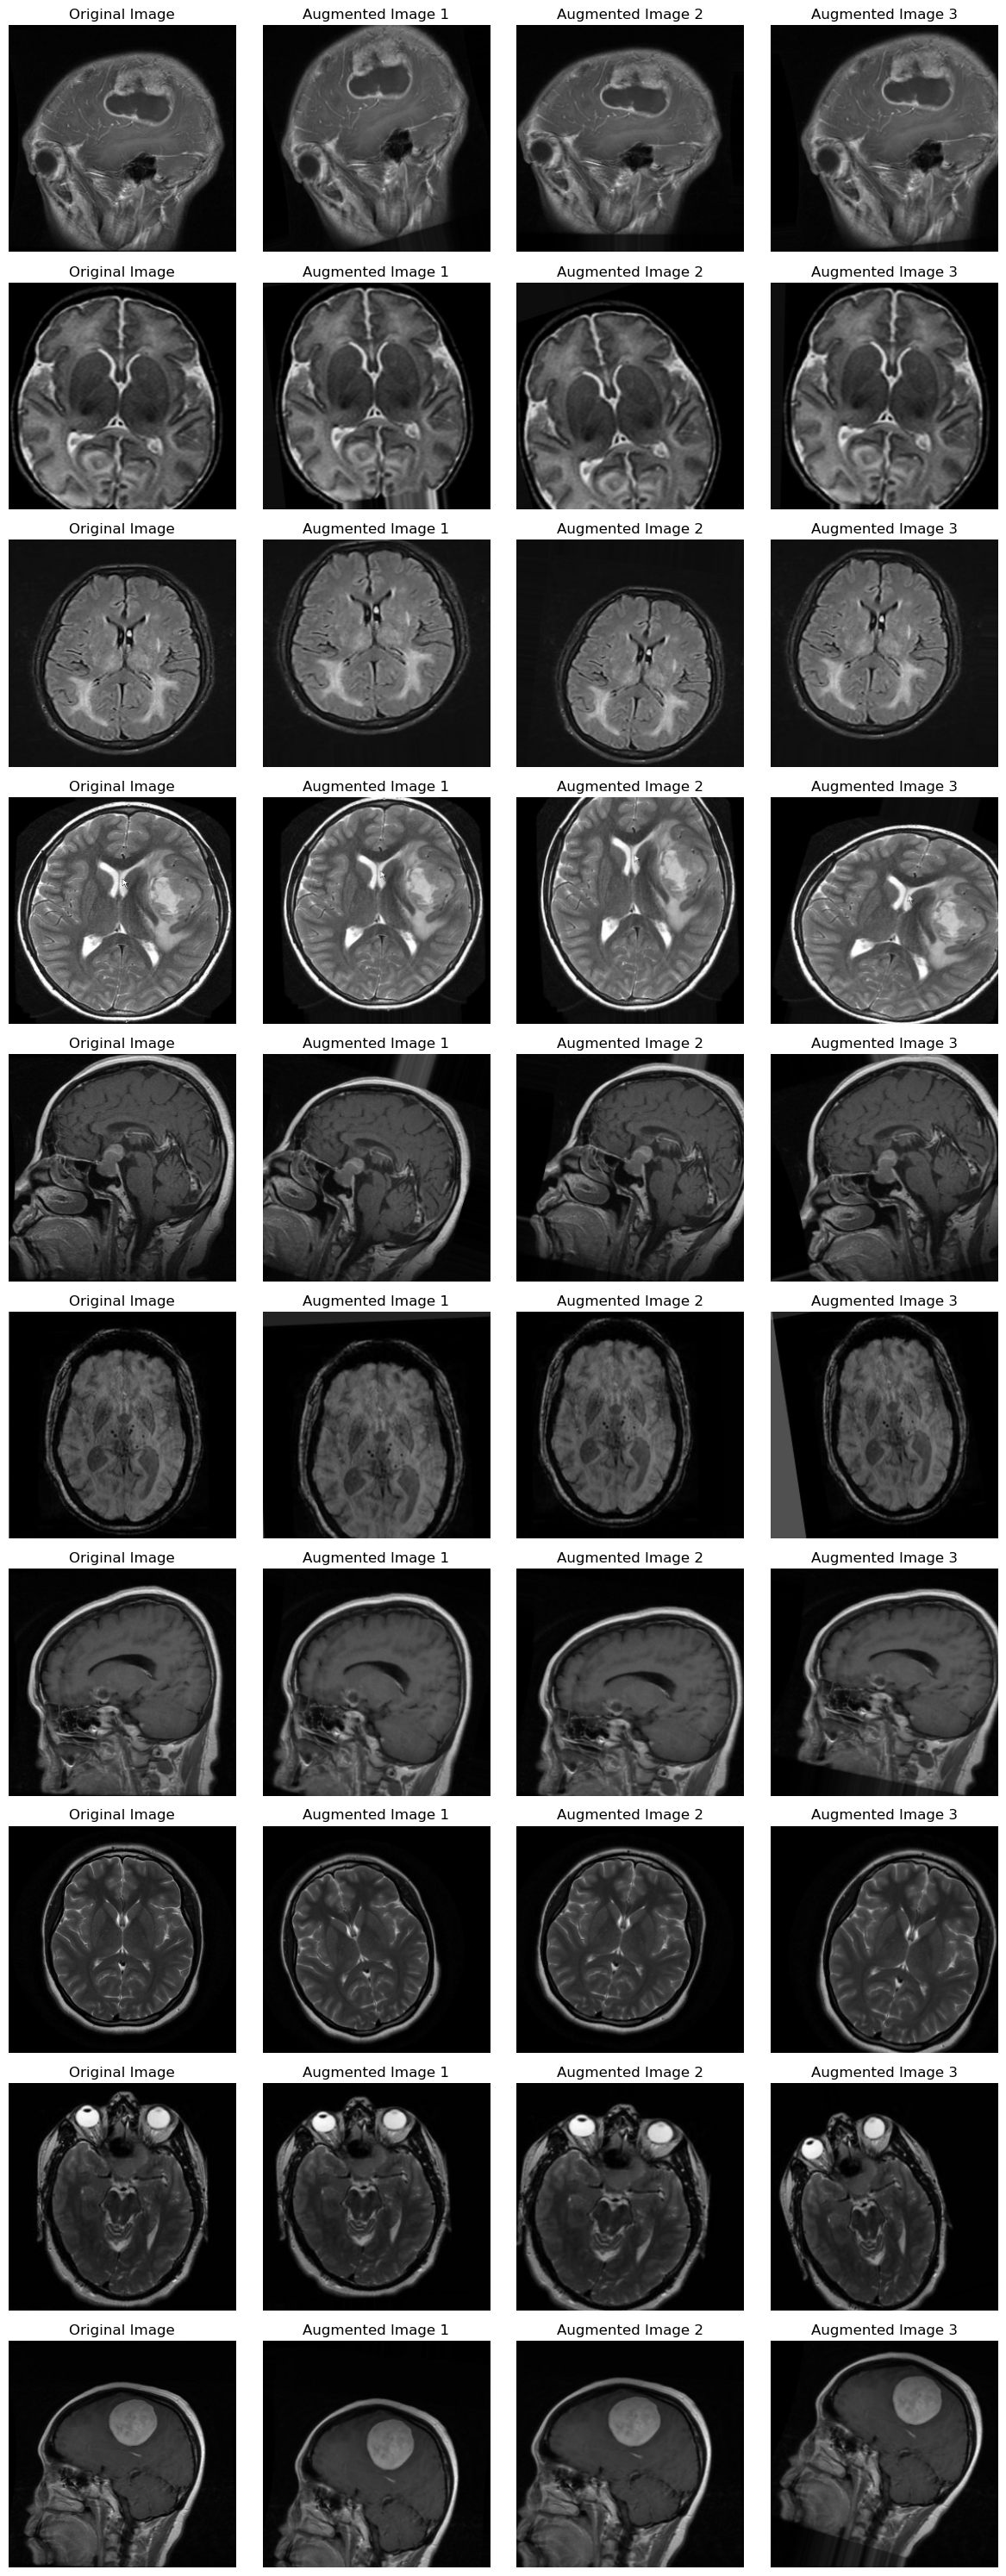

In [ ]:
visualize_augmented_images(datagen, num_samples=10, num_augmented_images=3)

In [ ]:
X_train_al_bt, y_train_al_bt = shuffle(X_train_al_bt, y_train_al_bt, random_state = 101)
X_train_al_bt.shape, y_train_al_bt.shape

((9664, 256, 256, 3), (9664,))

In [ ]:
X_train_al_bt, X_test_al_bt, y_train_al_bt, y_test_al_bt = train_test_split(X_train_al_bt, y_train_al_bt, test_size = 0.1, random_state = 101)

In [ ]:
y_train_new_al_bt = []
for i in y_train_al_bt:
    y_train_new_al_bt.append(labels_al_bt.index(i))

y_train_al_bt = y_train_new_al_bt
y_train_al_bt = tf.keras.utils.to_categorical(y_train_al_bt)

y_test_new_al_bt = []
for i in y_test_al_bt:
    y_test_new_al_bt.append(labels_al_bt.index(i))

y_test_al_bt = y_test_new_al_bt
y_test_al_bt = tf.keras.utils.to_categorical(y_test_al_bt)

In [ ]:
model_al_bt = unet_3d(input_shape, num_classes)

In [ ]:
model_al_bt.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 256, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_48 (Conv3D)  │ (None, 256, 256,  │      5,248 │ input_layer_10[0… │
│                     │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_12    │ (None, 128, 128,  │          0 │ conv3d_48[0][0]   │
│ (MaxPooling3D)      │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_49 (Conv3D)  │ (None, 128, 128,  │    221,312 │ max_pooling3d_12… │
│                     │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_13    │ (None, 64, 64,    │          0 │ conv3d_49[0][0]   │
│ (MaxPooling3D)      │ 64, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_50 (Conv3D)  │ (None, 64, 64,    │    884,992 │ max_pooling3d_13… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_14    │ (None, 32, 32,    │          0 │ conv3d_50[0][0]   │
│ (MaxPooling3D)      │ 32, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_51 (Conv3D)  │ (None, 32, 32,    │  3,539,456 │ max_pooling3d_14… │
│                     │ 32, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_12    │ (None, 64, 64,    │          0 │ conv3d_51[0][0]   │
│ (UpSampling3D)      │ 64, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_52 (Conv3D)  │ (None, 64, 64,    │  1,048,832 │ up_sampling3d_12… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_53 (Conv3D)  │ (None, 64, 64,    │  1,769,728 │ conv3d_52[0][0]   │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 64, 64,    │          0 │ conv3d_50[0][0],  │
│ (Concatenate)       │ 64, 512)          │            │ conv3d_53[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_54 (Conv3D)  │ (None, 64, 64,    │  3,539,200 │ concatenate_30[0… │
│                     │ 64, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_13    │ (None, 128, 128,  │          0 │ conv3d_54[0][0]   │
│ (UpSampling3D)      │ 128, 256)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_55 (Conv3D)  │ (None, 128, 128,  │    262,272 │ up_sampling3d_13… │
│                     │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_31      │ (None, 128, 128,  │          0 │ conv3d_49[0][0],  │
│ (Concatenate)       │ 128, 256)         │            │ conv3d_55[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_56 (Conv3D)  │ (None, 128, 128,  │    884,864 │ concatenate_31[0

 Total params: 12,443,012 (47.47 MB)

 Trainable params: 12,443,012 (47.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_al_bt.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy', Precision(), Recall()])

In [ ]:
history_al_bt = model_al_bt.fit(X_train_al_bt, y_train_al_bt, epochs = 110, validation_split = 0.1)

Epoch 1/110
245/245 ━━━━━━━━━━━━━━━━━━━━ 2234s 9s/step - accuracy: 0.3523 - loss: 2.1997 - precision: 0.4813 - recall: 0.1443 - val_accuracy: 0.5287 - val_loss: 1.0814 - val_precision: 0.6808 - val_recall: 0.1667
Epoch 2/110
245/245 ━━━━━━━━━━━━━━━━━━━━ 1860s 8s/step - accuracy: 0.5072 - loss: 1.1019 - precision: 0.6124 - recall: 0.2803 - val_accuracy: 0.5276 - val_loss: 1.0604 - val_precision: 0.6413 - val_recall: 0.2425
Epoch 3/110
245/245 ━━━━━━━━━━━━━━━━━━━━ 1913s 8s/step - accuracy: 0.5066 - loss: 1.0956 - precision: 0.6139 - recall: 0.2799 - val_accuracy: 0.5402 - val_loss: 1.0175 - val_precision: 0.5612 - val_recall: 0.4161
Epoch 4/110
245/245 ━━━━━━━━━━━━━━━━━━━━ 1887s 8s/step - accuracy: 0.5525 - loss: 0.9921 - precision: 0.6278 - recall: 0.3945 - val_accuracy: 0.5460 - val_loss: 1.0105 - val_precision: 0.6464 - val_recall: 0.2816
Epoch 5/110
245/245 ━━━━━━━━━━━━━━━━━━━━ 1884s 8s/step - accuracy: 0.5690 - loss: 0.9616 - precision: 0.6578 - recall: 0.3997 - val_accuracy: 0.5483

In [ ]:
def plot_training_curves(history):
    loss= np.array(history.history['loss'])
    val_loss= np.array(history.history['val_loss'])

    accuracy= np.array(history.history['accuracy'])
    val_accuracy= np.array(history.history['val_accuracy'])

    epochs= range(len(history.history['loss']))

    fig, (ax1, ax2)= plt.subplots(1,2,figsize=(10,3))

    #plot loss
    ax1.plot(epochs, loss, label='traing_loss', marker='o')

    ax1.plot(epochs, val_loss, label='val_loss', marker='o')

    ax1.fill_between(epochs,loss, val_loss, where=(loss>val_loss),color='C0',alpha=0.3,interpolate=True)
    ax1.fill_between(epochs,loss, val_loss, where=(loss<val_loss),color='C1',alpha=0.3,interpolate=True)

    ax1.set_title('Loss',fontsize= 16)
    ax1.set_xlabel('Epochs', fontsize=10)

    ax1.legend()

    #plot Accuracy
    ax2.plot(epochs, accuracy, label='traing_accuracy', marker='o')

    ax2.plot(epochs, val_accuracy, label='val_accuracy', marker='o')

    ax2.fill_between(epochs,accuracy, val_accuracy, where=(accuracy>val_accuracy),color='C0',alpha=0.3,interpolate=True)
    ax2.fill_between(epochs,accuracy, val_accuracy, where=(accuracy<val_accuracy),color='C1',alpha=0.3,interpolate=True)

    ax2.set_title('Accuracy',fontsize= 16)
    ax2.set_xlabel('Epochs', fontsize=10)

    ax2.legend()

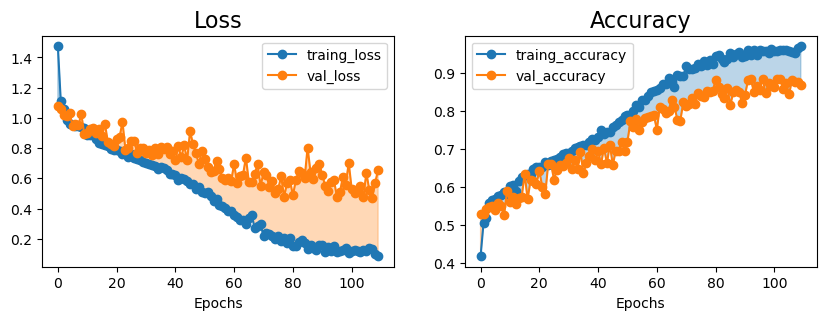

In [ ]:
plot_training_curves(history_al_bt)

In [ ]:
import dill
model_pkl_file = "CogniDetect_3dUnet_model.pkl"
with open(model_pkl_file, 'wb') as file:
    dill.dump(model_al_bt, file)

### **Testing Model Performance**

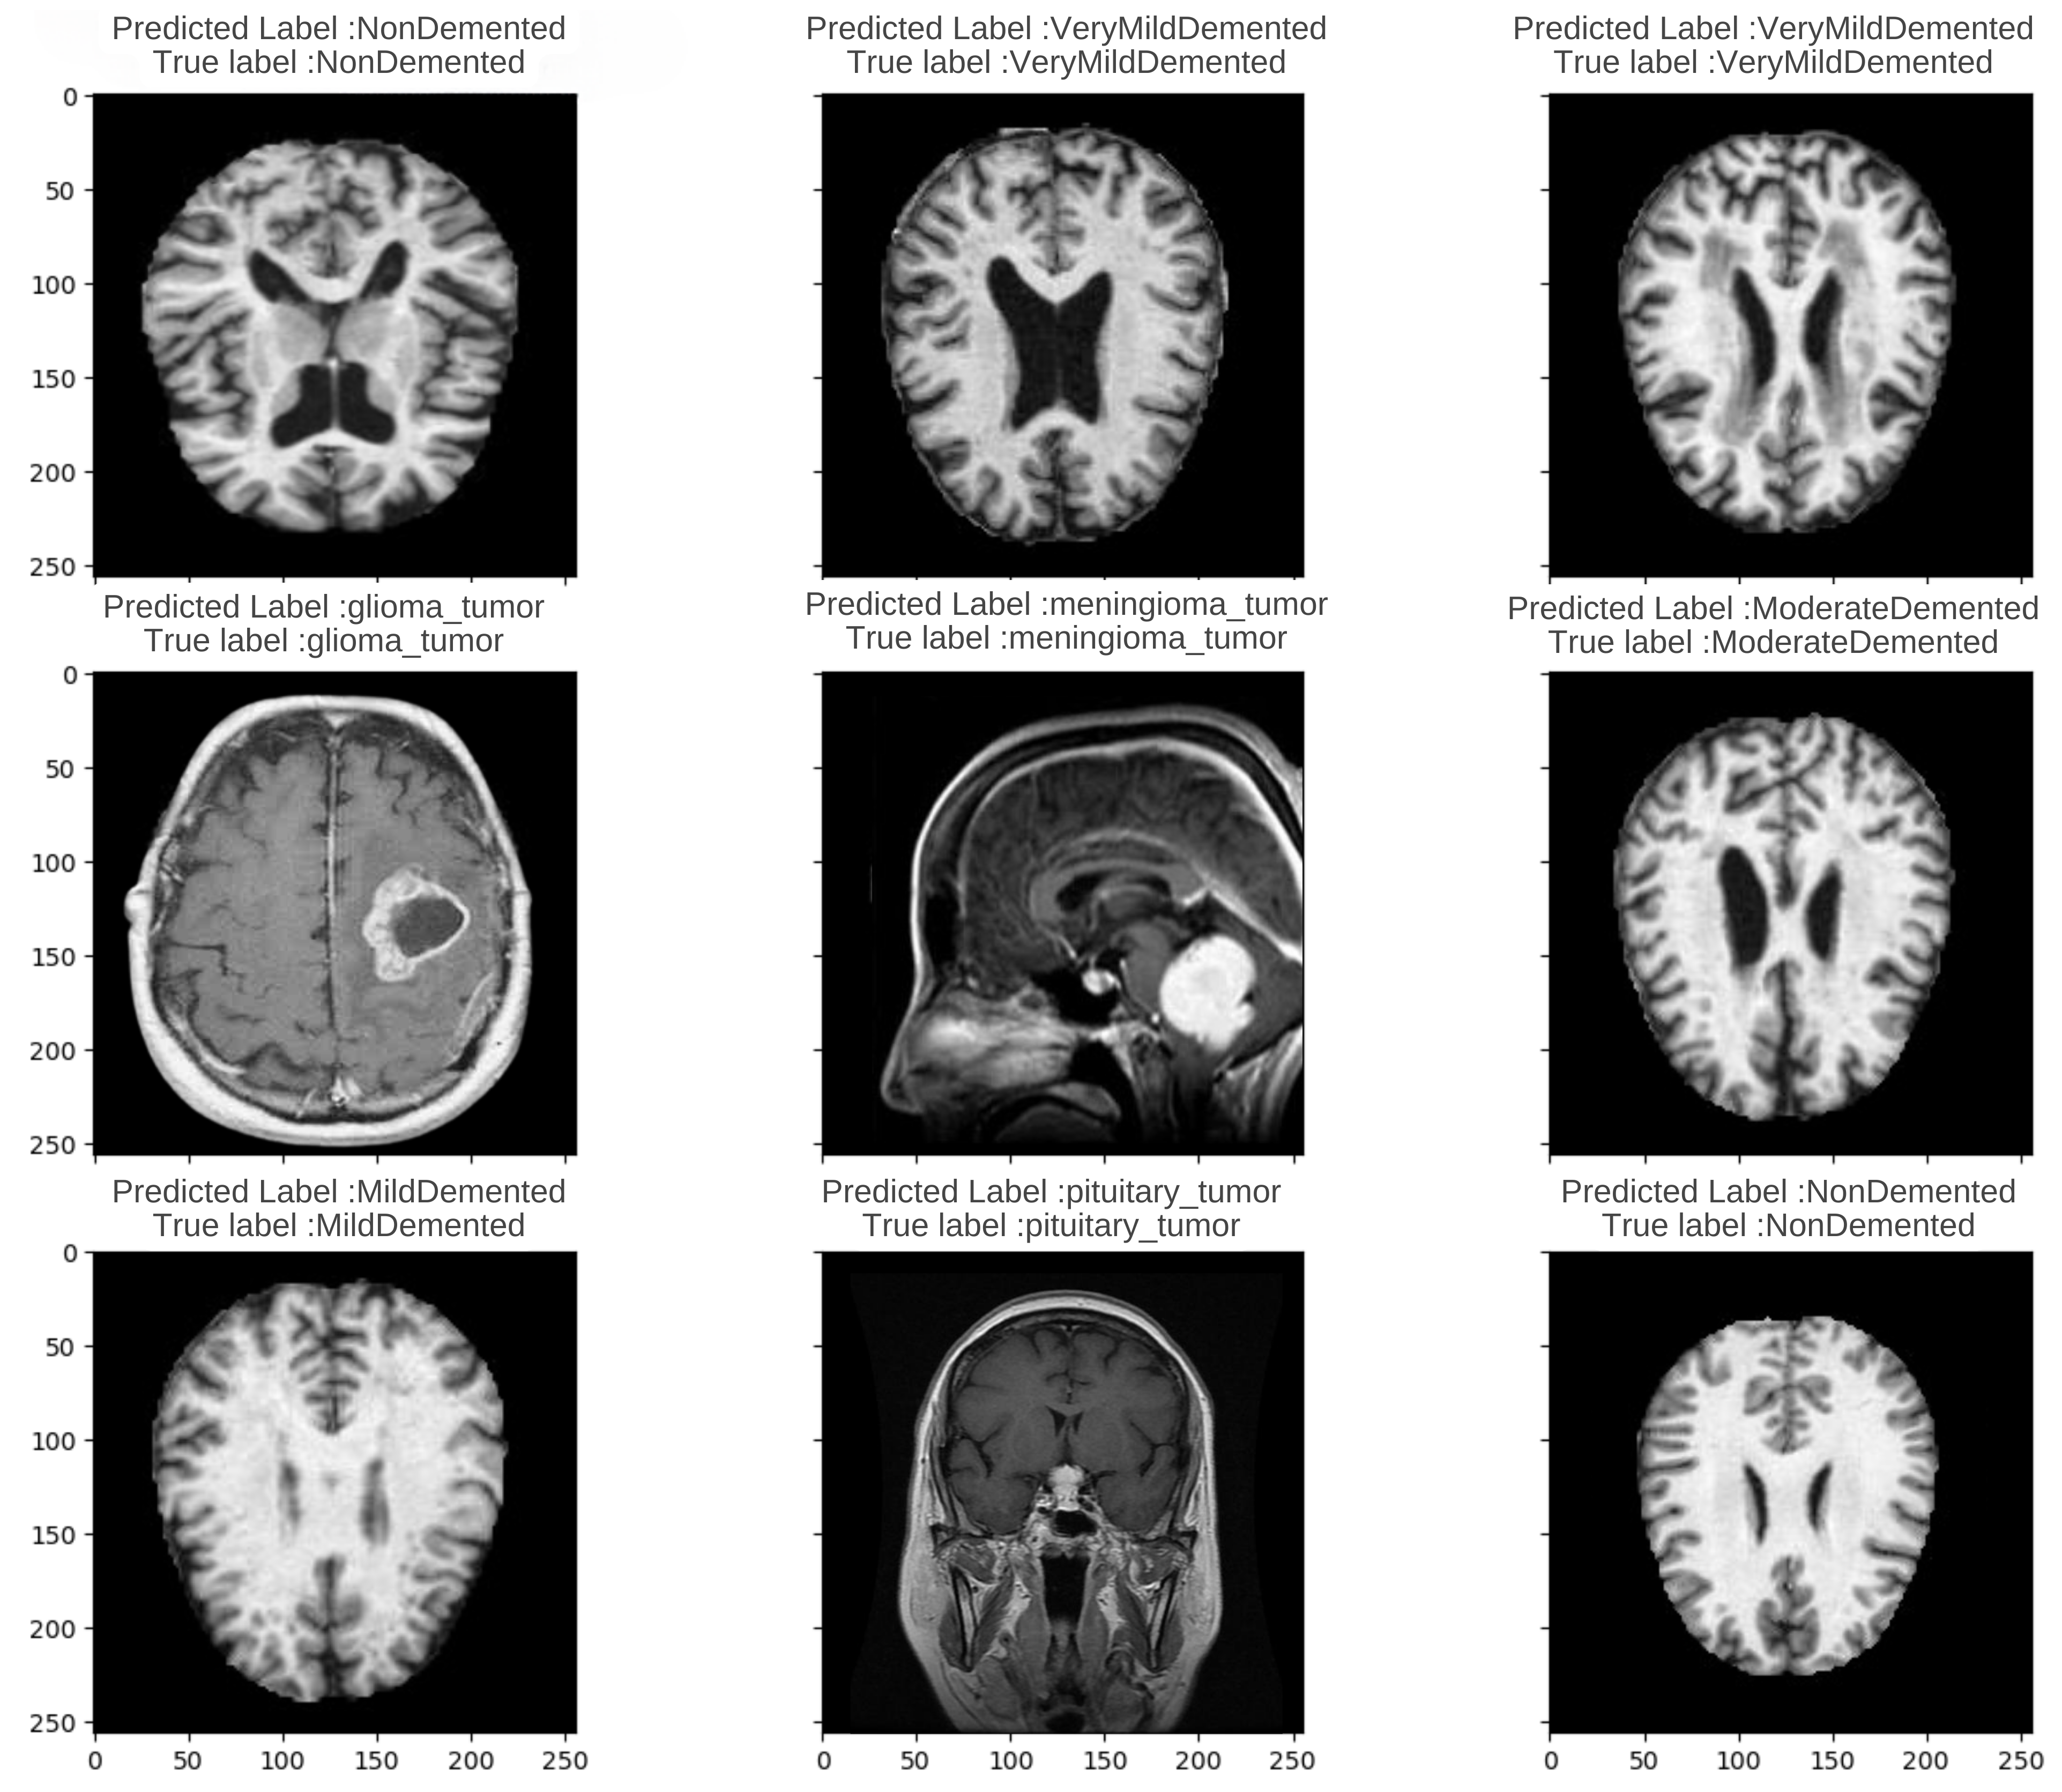

In [ ]:
import random
labels = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented', 'glioma_tumor', 'no_tumor', 'meningioma_tumor', 'pituitary_tumor']
imidx = random.sample(accurateindex, k=9)

nrows = 3
ncols = 3
fig, ax = plt.subplots(nrows,ncols,sharex=True,sharey=True,figsize=(15, 12))

n = 0
for row in range(nrows):
    for col in range(ncols):
            ax[row,col].imshow(X_test_al_bt[imidx[n]])
            ax[row,col].set_title("Predicted label :{}\nTrue label :{}".format(labels[np.argmax(ypred[imidx[n]])], labels[np.argmax(y_test_al_bt[imidx[n]])]))
            n += 1

plt.show()
